# 07 – Model comparison: Secondary Mushroom

**Worked on by:** Andreas Schellekens (comparison protocol, bootstrap of the differences, permutation importance, error analysis, choice of the deployed model)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the models of `03_model_baseline.ipynb` to `05c_model_ensemble.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

This notebook brings all models together and answers three questions:
1. **Which model do we deploy?** Decided on the **validation set**, the set that was made for choices like this (notebook 02, section 6).
2. **How good is it really?** Reported on the **test set**, which no choice has used so far.
3. **What does the model look at, and where does it go wrong?** Permutation importance and an error analysis of the poisonous mushrooms it misses.

Nothing is trained here: we load the saved models and compare their predictions on exactly the same rows. The AWS model (`06_model_aws.ipynb`) does not exist yet; it will be added here when it does.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
METRICS_PATH = MODEL_DIR / "metrics.csv"

RANDOM_STATE = 42
RECALL_TARGET = 0.90
INPUT_COLS = ["cap_diameter", "stem_height", "stem_width", "has_stem", "spore_print_color", "gill_color", "habitat",
              "season", "ring_type", "cap_shape", "stem_surface"]
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_cleaned_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

## 2. All test and validation metrics so far

Every model notebook wrote its results to `models/metrics.csv`: one row per model, set and threshold. This is the overview of everything we trained, including the naive model and PyCaret's random forest. Rows with a threshold below 0.5 are the tuned operating points (90% recall on validation).

In [2]:
metrics = pd.read_csv(METRICS_PATH)
columns = ["threshold", "roc_auc", "accuracy", "recall_poisonous", "precision_poisonous", "missed_poisonous", "false_alarms"]
for split in ["validation", "test"]:
    print(f"\n{split.upper()} SET")
    display(metrics[metrics["split"] == split].set_index("model")[columns].round(3))


VALIDATION SET


,threshold,roc_auc,accuracy,recall_poisonous,precision_poisonous,missed_poisonous,false_alarms
model,,,,,,,
naive (always edible),0.500,0.500,0.621,0.000,0.000,284,0
logistic regression (balanced),0.500,0.704,0.656,0.623,0.540,107,151
PyCaret random forest (default),0.500,0.818,0.803,0.648,0.793,100,48
random forest (tuned),0.500,0.817,0.800,0.634,0.796,104,46
"random forest (tuned, recall 0.90)",0.161,0.817,0.564,0.901,0.461,28,299
gradient boosting (tuned),0.500,0.819,0.799,0.634,0.793,104,47
"gradient boosting (tuned, recall 0.90)",0.139,0.819,0.573,0.901,0.467,28,292
ensemble (stack: forest + boosting),0.500,0.821,0.801,0.669,0.776,94,55
"ensemble (stack: forest + boosting), recall 0.90",0.130,0.821,0.575,0.901,0.468,28,291



TEST SET


,threshold,roc_auc,accuracy,recall_poisonous,precision_poisonous,missed_poisonous,false_alarms
model,,,,,,,
naive (always edible),0.500,0.500,0.621,0.000,0.000,284,0
logistic regression (balanced),0.500,0.711,0.677,0.630,0.566,105,137
PyCaret random forest (default),0.500,0.838,0.785,0.606,0.778,112,49
random forest (tuned),0.500,0.842,0.795,0.613,0.798,110,44
"random forest (tuned, recall 0.90)",0.161,0.842,0.579,0.930,0.471,20,296
gradient boosting (tuned),0.500,0.847,0.808,0.623,0.827,107,37
"gradient boosting (tuned, recall 0.90)",0.139,0.847,0.576,0.940,0.470,17,301
ensemble (stack: forest + boosting),0.500,0.851,0.811,0.662,0.803,96,46
"ensemble (stack: forest + boosting), recall 0.90",0.130,0.851,0.581,0.923,0.473,22,292


**Interpretation**
- **Three levels:** the naive model (62% accuracy, catches nothing), the linear baseline (AUC 0.70–0.71) and the tree models (AUC 0.82 on validation, 0.84–0.85 on test). Everything with trees is far ahead of everything without.
- **Every model scores higher on the test set than on the validation set** (AUC +0.02 to +0.03). Because it is the same direction for all models, it is a property of the two sets of 750 mushrooms (the test set is a little easier), not of a model. This is why we compare models on the *same* rows below.
- **At threshold 0.5** every tree model misses about 100 of the 284 poisonous mushrooms. **At the tuned thresholds** that drops to about 20, for about 300 false alarms out of 466 edible mushrooms.
- PyCaret's default forest and our tuned forest are almost equal (validation AUC 0.818 vs. 0.817, test 0.838 vs. 0.842): tuning the forest gave only a small gain.

## 3. The candidates, on the same rows

To compare models properly, we need their **probabilities** for the same mushrooms, not only the summary numbers. We load the four deployable models (all scikit-learn pipelines that take the 11 cleaned columns):

| Candidate | Notebook |
|---|---|
| logistic regression (balanced) | 03 |
| random forest (tuned) | 05a |
| gradient boosting (tuned, native missing values) | 05b |
| heterogeneous ensemble | 05c |

Not in this part: the naive model (it predicts nothing) and PyCaret's random forest (it needs PyCaret to run, and the tuned forest of 05a is the better version of the same model). Their numbers are in the table above.

**One operating point for all.** We compare the models where we would use them: at the threshold that catches 90% of the poisonous validation mushrooms. 05a–05c chose that threshold on the validation set and stored it in their JSON file. We recompute it here with the same rule and check that it matches; the baseline never got a tuned threshold (notebook 03 used 0.5), so it gets one here in the same way.

In [3]:
def load_cleaned(split):
    frame = pd.read_csv(data_path(split, "cleaned"), index_col="row_id")
    return frame, (frame["class"] == "poisonous").astype(int)


def threshold_for_recall(y_true, p, target):
    # Highest threshold whose recall is still >= target (same rule as 05a-05c)
    _, recall, thresholds = precision_recall_curve(y_true, p)
    return thresholds[recall[:-1] >= target].max()


val_df, y_val = load_cleaned("validation")
test_df, y_test = load_cleaned("test")
X = {"validation": val_df[INPUT_COLS], "test": test_df[INPUT_COLS]}
y = {"validation": y_val, "test": y_test}

CANDIDATES = {
    "logistic regression (03)": "mushroom_baseline",
    "random forest (05a)": "mushroom_random_forest",
    "gradient boosting (05b)": "mushroom_gradient_boosting",
    "ensemble (05c)": "mushroom_ensemble",
}
models, probs, thresholds, size_mb = {}, {"validation": {}, "test": {}}, {}, {}
for name, file in CANDIDATES.items():
    models[name] = joblib.load(MODEL_DIR / f"{file}.joblib")
    size_mb[name] = (MODEL_DIR / f"{file}.joblib").stat().st_size / 1e6
    for split in ["validation", "test"]:
        probs[split][name] = models[name].predict_proba(X[split])[:, 1]
    thresholds[name] = threshold_for_recall(y_val, probs["validation"][name], RECALL_TARGET)
    info_path = MODEL_DIR / f"{file}.json"
    if info_path.exists():
        assert abs(thresholds[name] - json.loads(info_path.read_text())["threshold"]) < 1e-4, f"{name}: threshold differs"

pd.Series(thresholds, name="threshold for 90% recall on validation").round(3)

logistic regression (03)    0.330
random forest (05a)         0.161
gradient boosting (05b)     0.139
ensemble (05c)              0.130
Name: threshold for 90% recall on validation, dtype: float64

## 4. Choosing the deployed model (validation set)

**What counts?** In order of importance:
1. **False alarms at 90% recall.** All candidates catch (at least) 90% of the poisonous validation mushrooms at their threshold; the better model throws away fewer edible mushrooms to get there. This is the number a user notices.
2. **ROC-AUC:** how well the model ranks poisonous above edible over *all* thresholds. It tells us how the model would do if we later chose a different recall target.
3. **Size and simplicity:** a smaller model is cheaper to host, faster to load and retrain, and easier to explain.

**Is a difference real?** The validation set has 750 mushrooms, so small differences can be luck. We use a **paired bootstrap**: draw 750 validation mushrooms *with replacement* (some twice, some not at all), compute every model's AUC, false alarms and missed poisonous mushrooms on that sample, and repeat 2000 times. Because all models are scored on the *same* sample each time, the variation that comes from "an easy or a hard sample" cancels out in the difference. The middle 95% of the 2000 differences is the **95% confidence interval**: if it contains 0, we cannot tell the two models apart.

The reference is the random forest (05a), the best model in cross-validation so far. A caveat: the thresholds themselves were chosen on this validation set, so the bootstrap ignores the uncertainty of the threshold. That is why the test set (section 5) has the final word on *how good* the chosen model is.

In [4]:
def operating_table(split):
    rows = {}
    for name in CANDIDATES:
        p, t, yt = probs[split][name], thresholds[name], y[split].to_numpy()
        pred = p >= t
        rows[name] = {"roc_auc": roc_auc_score(yt, p), "threshold": t,
                      "recall": pred[yt == 1].mean(), "precision": yt[pred].mean(),
                      "missed_poisonous": int((~pred & (yt == 1)).sum()), "false_alarms": int((pred & (yt == 0)).sum()),
                      "size_MB": size_mb[name]}
    return pd.DataFrame(rows).T


def paired_bootstrap(split, reference="random forest (05a)", n_boot=2000):
    rng = np.random.default_rng(RANDOM_STATE)
    yt = y[split].to_numpy()

    def scores(idx):
        out = {}
        for name in CANDIDATES:
            p, yb = probs[split][name][idx], yt[idx]
            pred = p >= thresholds[name]
            out[name] = (roc_auc_score(yb, p), (pred & (yb == 0)).sum(), (~pred & (yb == 1)).sum())
        return out

    observed = scores(np.arange(len(yt)))
    boot = [scores(rng.integers(0, len(yt), len(yt))) for _ in range(n_boot)]
    rows = {}
    for name in CANDIDATES:
        if name == reference:
            continue
        for k, metric in enumerate(["roc_auc", "false_alarms", "missed_poisonous"]):
            diffs = np.array([b[name][k] - b[reference][k] for b in boot])
            rows[(name, metric)] = {"difference": observed[name][k] - observed[reference][k],
                                    "ci_95_low": np.percentile(diffs, 2.5), "ci_95_high": np.percentile(diffs, 97.5)}
    return pd.DataFrame(rows).T


display(operating_table("validation").round(3))
print("Difference with the random forest (05a) on the validation set; negative false alarms / missed = better:")
paired_bootstrap("validation").round(3)

,roc_auc,threshold,recall,precision,missed_poisonous,false_alarms,size_MB
logistic regression (03),0.704,0.330,0.901,0.420,28.0,353.0,0.009
random forest (05a),0.817,0.161,0.901,0.461,28.0,299.0,26.470
gradient boosting (05b),0.819,0.139,0.901,0.467,28.0,292.0,0.999
ensemble (05c),0.821,0.130,0.901,0.468,28.0,291.0,27.420


Difference with the random forest (05a) on the validation set; negative false alarms / missed = better:


difference  ci_95_low  ci_95_high
logistic regression (03) roc_auc               -0.113     -0.149      -0.077
                         false_alarms          54.000     28.000      77.000
                         missed_poisonous       0.000    -12.000      12.000
gradient boosting (05b)  roc_auc                0.003     -0.012       0.017
                         false_alarms          -7.000    -27.000      12.000
                         missed_poisonous       0.000     -9.000       9.000
ensemble (05c)           roc_auc                0.004     -0.001       0.009
                         false_alarms          -8.000    -19.000       2.000
                         missed_poisonous       0.000     -6.000       6.000

**Interpretation**
- **The operating point is the same for every model:** all catch 90.1% of the poisonous validation mushrooms (28 missed), because every threshold was chosen that way. The difference is in the false alarms: logistic regression 353, random forest 299, gradient boosting 292, ensemble 291 (out of 466 edible mushrooms).
- **The baseline is clearly worse:** 54 more false alarms than the forest (95% interval 28 to 77) and an AUC that is 0.11 lower. Both intervals are far from 0.
- **The three tree models cannot be told apart.** Against the forest, gradient boosting has 7 fewer false alarms, but the interval runs from 27 fewer to 12 more; the ensemble has 8 fewer (19 fewer to 2 more), with an AUC gain of 0.004 whose interval just touches 0. The ensemble is consistently a hair better than the forest, but a hair means about 1–2% of the edible mushrooms.
- **Size and speed are very different** (section 8): gradient boosting is 1.0 MB and answers one mushroom in about 5 ms; the forest (26 MB) and the ensemble (27 MB) take 10–12 times longer, and are too large to keep in git, so the deployment would have to rebuild them.

**Decision: we deploy the gradient boosting model (05b).** It is as good as the best model at our operating point (292 vs. 291 false alarms, AUC 0.819 vs. 0.821), it is about 27 times smaller and 10 to 12 times faster than the forest and the ensemble, it is one model instead of two to explain and to retrain, and it handles missing values itself. The ensemble's small edge in AUC is not worth that cost.

The cell below repeats the bootstrap with the deployed model as the reference, to check that no candidate is clearly better: the forest scores 0.003 lower in AUC (interval −0.017 to +0.012) with 7 more false alarms (−12 to +27), the ensemble 0.001 higher (−0.009 to +0.012) with 1 fewer false alarm (−16 to +15). Every interval contains 0.

In [5]:
DEPLOYED = "gradient boosting (05b)"
assert DEPLOYED in CANDIDATES
print(f"Deployed model: {DEPLOYED}  ->  models/{CANDIDATES[DEPLOYED]}.joblib, threshold {thresholds[DEPLOYED]:.4f}")
print(f"\nDifference with the deployed model on the validation set; negative false alarms / missed = better:")
paired_bootstrap("validation", reference=DEPLOYED).round(3)

Deployed model: gradient boosting (05b)  ->  models/mushroom_gradient_boosting.joblib, threshold 0.1390

Difference with the deployed model on the validation set; negative false alarms / missed = better:


difference  ci_95_low  ci_95_high
logistic regression (03) roc_auc               -0.115     -0.150      -0.083
                         false_alarms          61.000     37.975      84.000
                         missed_poisonous       0.000    -10.025      11.000
random forest (05a)      roc_auc               -0.003     -0.017       0.012
                         false_alarms           7.000    -12.000      27.000
                         missed_poisonous       0.000     -9.000       9.000
ensemble (05c)           roc_auc                0.001     -0.009       0.012
                         false_alarms          -1.000    -16.000      15.000
                         missed_poisonous       0.000     -7.000       7.025

## 5. Final report on the test set

Now that the choice is made, we look at the test set: 750 mushrooms that no choice has used. The same table as in section 4, the paired bootstrap now against the deployed model, plus the ROC and precision-recall curves of all candidates. The dots mark each model's operating point (its validation threshold).

These numbers are only *reported*. If the test set disagreed with the validation set, we would mention it, but not change the choice: choosing again on the test set would turn it into a second validation set, and we would have no honest estimate left.

,roc_auc,threshold,recall,precision,missed_poisonous,false_alarms,size_MB
logistic regression (03),0.711,0.330,0.877,0.416,35.0,349.0,0.009
random forest (05a),0.842,0.161,0.930,0.471,20.0,296.0,26.470
gradient boosting (05b),0.847,0.139,0.940,0.470,17.0,301.0,0.999
ensemble (05c),0.851,0.130,0.923,0.473,22.0,292.0,27.420


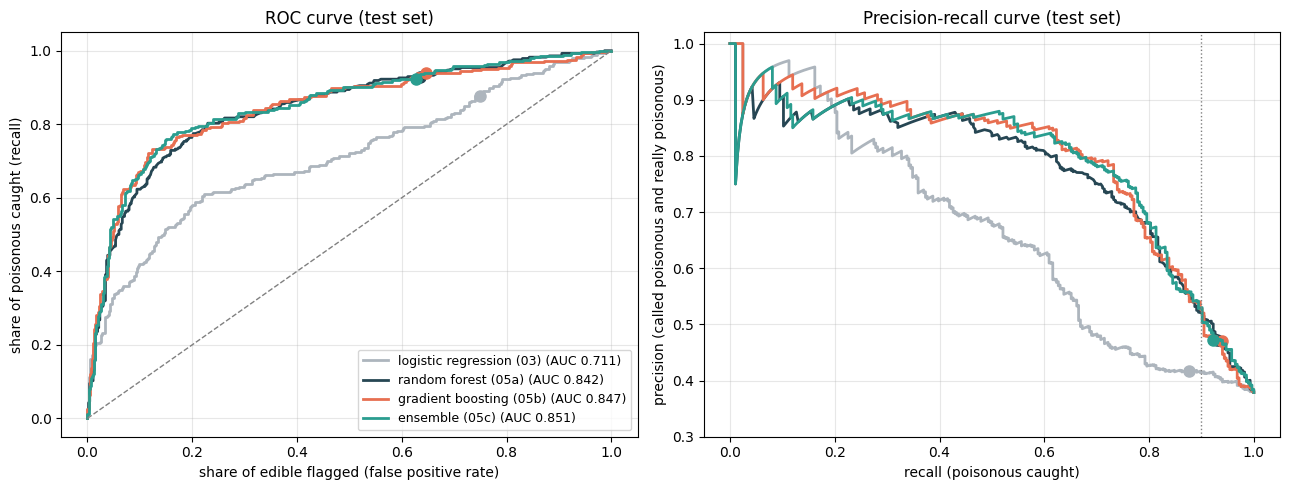

In [6]:
display(operating_table("test").round(3))

colors = {"logistic regression (03)": "#adb5bd", "random forest (05a)": "#264653",
          "gradient boosting (05b)": "#e76f51", "ensemble (05c)": "#2a9d8f"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in CANDIDATES:
    p, yt = probs["test"][name], y_test.to_numpy()
    pred = p >= thresholds[name]
    fpr, tpr, _ = roc_curve(yt, p)
    axes[0].plot(fpr, tpr, color=colors[name], lw=2, label=f"{name} (AUC {roc_auc_score(yt, p):.3f})")
    axes[0].plot(pred[yt == 0].mean(), pred[yt == 1].mean(), "o", color=colors[name], ms=8)
    precision, recall, _ = precision_recall_curve(yt, p)
    axes[1].plot(recall, precision, color=colors[name], lw=2, label=name)
    axes[1].plot(pred[yt == 1].mean(), yt[pred].mean(), "o", color=colors[name], ms=8)
axes[0].plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
axes[0].set(title="ROC curve (test set)", xlabel="share of edible flagged (false positive rate)",
            ylabel="share of poisonous caught (recall)")
axes[1].axvline(RECALL_TARGET, color="gray", ls=":", lw=1)
axes[1].set(title="Precision-recall curve (test set)", xlabel="recall (poisonous caught)",
            ylabel="precision (called poisonous and really poisonous)", ylim=(0.3, 1.02))
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
print(f"Difference with the deployed model ({DEPLOYED}) on the test set; negative false alarms / missed = better:")
paired_bootstrap("test", reference=DEPLOYED).round(3)

Difference with the deployed model (gradient boosting (05b)) on the test set; negative false alarms / missed = better:


difference  ci_95_low  ci_95_high
logistic regression (03) roc_auc               -0.135     -0.170      -0.101
                         false_alarms          48.000     28.000      68.000
                         missed_poisonous      18.000      7.000      30.000
random forest (05a)      roc_auc               -0.004     -0.021       0.012
                         false_alarms          -5.000    -24.025      14.000
                         missed_poisonous       3.000     -4.000      11.000
ensemble (05c)           roc_auc                0.004     -0.007       0.015
                         false_alarms          -9.000    -26.000       8.000
                         missed_poisonous       5.000     -2.000      12.000

**Interpretation**
- **The test set confirms the validation set.** The three tree models are again close together (AUC 0.842–0.851) and the baseline is far behind (0.711). The curves show the same: the three tree curves lie on top of each other over the whole range, and at 90% recall all three have a precision of about 0.47.
- **The deployed model on the test set:** AUC 0.847, recall **0.94** (267 of 284 poisonous mushrooms caught, **17 missed**), 301 of 466 edible mushrooms flagged (precision 0.47).
- Against the deployed model, the forest and the ensemble are not significantly different on any measure (all intervals contain 0); the ensemble has 9 fewer false alarms but 5 more missed poisonous mushrooms. The baseline misses 18 more poisonous mushrooms (interval 7 to 30), the only significant difference.
- **The test recall (0.92–0.94) is above the 90% target for all three**, because the test set is a little easier than the validation set where the thresholds were chosen. For new mushrooms we should therefore expect roughly 90–94% of the poisonous mushrooms to be caught, at the cost of flagging about two thirds of the edible ones.
- The validation choice stands; nothing on the test set would have changed it.

## 6. What does the deployed model look at?

Notebook 04 showed the random forest's *impurity-based* importance, and warned that it favours features with many possible split points (the continuous sizes). **Permutation importance** is a fairer check that works for any model, including an ensemble:
1. score the model on the validation set (ROC-AUC);
2. shuffle one column, so its link with the class is broken while its distribution stays the same, and score again;
3. the drop in AUC is how much the model relies on that column. Repeated 20 times per column with different shuffles.

We permute the 11 **cleaned** columns, not the 64 one-hot columns: shuffling `habitat` as a whole is a meaningful question ("how much does the model need the habitat?"), shuffling one one-hot column alone would create impossible mushrooms (two habitats at once). We use the validation set, because importance on the training set would also reward what the model memorised.

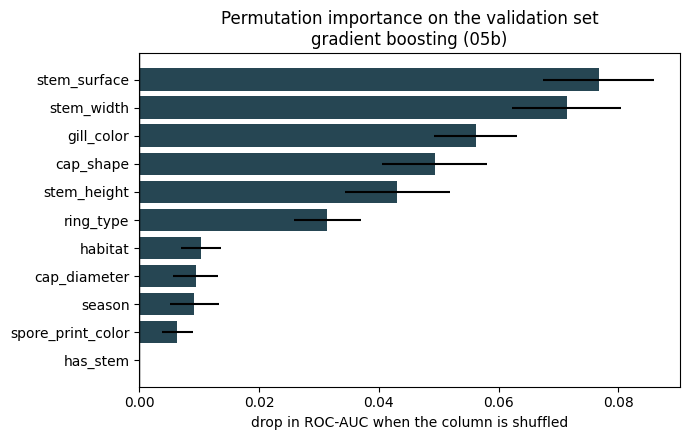

,stem_surface,stem_width,gill_color,cap_shape,stem_height,ring_type,habitat,cap_diameter,season,spore_print_color,has_stem
mean,0.0767,0.0714,0.0562,0.0493,0.0431,0.0314,0.0103,0.0094,0.0092,0.0064,0.0
std,0.0093,0.0091,0.0069,0.0088,0.0087,0.0056,0.0033,0.0037,0.0040,0.0025,0.0


In [8]:
importance = permutation_importance(models[DEPLOYED], X["validation"], y_val, scoring="roc_auc", n_repeats=20,
                                    random_state=RANDOM_STATE)
imp = pd.DataFrame({"mean": importance.importances_mean, "std": importance.importances_std},
                   index=INPUT_COLS).sort_values("mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp.index, imp["mean"], xerr=imp["std"], color="#264653")
ax.axvline(0, color="k", lw=1)
ax.set(title=f"Permutation importance on the validation set\n{DEPLOYED}", xlabel="drop in ROC-AUC when the column is shuffled")
plt.tight_layout()
plt.show()
imp.sort_values("mean", ascending=False).round(4).T

**Interpretation**
- **Most important:** `stem_surface` (a drop of 0.077 in AUC when shuffled), `stem_width` (0.071), `gill_color` (0.056), `cap_shape` (0.049), `stem_height` (0.043) and `ring_type` (0.031). Categories and sizes both matter.
- This is a different picture than the random forest's *impurity* importance in notebook 04, where the three sizes dominated. Part of that was the bias the caveat in 04 warned about: impurity importance favours continuous features with many split points. Permutation importance does not have that bias.
- **`cap_diameter` seems unimportant (0.009), but it is not useless.** It is missing for 41% of the mushrooms, and it is strongly correlated with `stem_width` (Spearman 0.85, EDA section 8): when `cap_diameter` is shuffled, `stem_width` still carries most of the size information. Correlated features share their importance, so permutation importance underestimates both.
- `stem_surface` is on top partly because of its *missing* values: for this column, being missing is related to the class (EDA 5.2), and the model uses that.
- `spore_print_color` (95% missing) and `has_stem` add little here: only a handful of validation mushrooms have a spore print colour or no stem, and for stemless mushrooms the stem sizes of 0 carry the same information. A low importance on 750 rows does not mean these columns never matter: for the few mushrooms where they apply they are strong signals (EDA 7.1).

## 7. Error analysis: which poisonous mushrooms are missed?

At its threshold the deployed model still misses about 1 in 10 poisonous mushrooms. Are these random, or do they have something in common? We look at the **validation set**, the set we are allowed to learn from, and split it into four groups by the deployed model's decision:
- **missed poisonous** (false negatives: the dangerous error),
- **caught poisonous** (true positives),
- **false alarms** (edible, but called poisonous),
- **correctly edible** (true negatives).

For every group we compare the predicted probability, how many of the 11 inputs are missing, the sizes, and a few categories that the EDA found important.

In [9]:
p_deployed = probs["validation"][DEPLOYED]
called_poisonous = p_deployed >= thresholds[DEPLOYED]
truth = y_val.to_numpy() == 1
group = np.select([truth & ~called_poisonous, truth & called_poisonous, ~truth & called_poisonous],
                  ["missed poisonous", "caught poisonous", "false alarm"], default="correctly edible")

analysis = val_df.assign(group=group, probability=p_deployed,
                         n_missing=(val_df[INPUT_COLS].isna() | (val_df[INPUT_COLS] == "missing")).sum(axis=1))
profile = analysis.groupby("group").agg(
    mushrooms=("probability", "size"),
    median_probability=("probability", "median"),
    mean_missing_inputs=("n_missing", "mean"),
    cap_diameter_missing=("cap_diameter", lambda s: s.isna().mean()),
    median_cap_diameter=("cap_diameter", "median"),
    median_stem_width=("stem_width", "median"),
    has_stem=("has_stem", "mean"),
    ring_type_none=("ring_type", lambda s: (s == "none").mean()),
    stem_surface_missing=("stem_surface", lambda s: (s == "missing").mean()),
    habitat_woods=("habitat", lambda s: (s == "woods").mean()),
).loc[["missed poisonous", "caught poisonous", "false alarm", "correctly edible"]]
profile.round(2).T

group,missed poisonous,caught poisonous,false alarm,correctly edible
mushrooms,28.00,256.00,292.00,174.00
median_probability,0.10,0.71,0.29,0.09
mean_missing_inputs,3.04,3.09,3.26,3.00
cap_diameter_missing,0.21,0.46,0.43,0.34
median_cap_diameter,7.37,4.84,6.20,7.14
median_stem_width,17.50,7.25,9.44,14.03
has_stem,1.00,0.95,0.99,1.00
ring_type_none,0.68,0.75,0.80,0.63
stem_surface_missing,0.61,0.62,0.71,0.70
habitat_woods,0.71,0.59,0.60,0.61


Two more questions about the missed poisonous mushrooms:
- **Do the other models miss them too?** If every model misses the same mushrooms, the problem is in the data (missing information, or a flipped label), not in the choice of model.
- **How sure is the model?** A poisonous mushroom that gets a probability far below the threshold looks completely edible to the model. Those are the candidates for flipped labels from the EDA (section 9).

In [10]:
missed = analysis[analysis["group"] == "missed poisonous"].copy()
missed_by = pd.DataFrame({name: probs["validation"][name] < thresholds[name] for name in CANDIDATES}, index=val_df.index)
missed["other_models_that_miss_it"] = missed_by.loc[missed.index].drop(columns=DEPLOYED).sum(axis=1)

print(f"Missed poisonous mushrooms: {len(missed)}")
print("Number of the 3 other candidates that also miss them:")
print(missed["other_models_that_miss_it"].value_counts().sort_index().to_string())
print(f"Missed with probability below half the threshold: {(missed['probability'] < thresholds[DEPLOYED] / 2).sum()}")
missed.sort_values("probability")[["probability", "other_models_that_miss_it", "n_missing"] + INPUT_COLS].round(3)

Missed poisonous mushrooms: 28
Number of the 3 other candidates that also miss them:
other_models_that_miss_it
0     4
1     5
2    11
3     8
Missed with probability below half the threshold: 7


,probability,other_models_that_miss_it,n_missing,cap_diameter,stem_height,stem_width,has_stem,spore_print_color,gill_color,habitat,season,ring_type,cap_shape,stem_surface
row_id,,,,,,,,,,,,,,
642,0.037,3,3,18.95,22.98,18.71,1.0,missing,white,meadows,missing,movable,spherical,missing
4837,0.038,3,3,13.26,9.78,17.63,1.0,missing,white,woods,summer,missing,convex,missing
1392,0.040,3,3,15.56,9.74,17.61,1.0,missing,white,woods,summer,missing,convex,missing
4786,0.047,1,3,5.24,8.80,11.04,1.0,missing,black,woods,missing,missing,spherical,smooth
4319,0.053,3,2,5.11,12.30,10.39,1.0,missing,white,missing,summer,none,convex,smooth
3060,0.062,3,3,9.46,NaN,19.31,1.0,missing,buff,woods,autumn,none,flat,missing
1501,0.064,2,3,8.34,NaN,19.67,1.0,missing,white,woods,autumn,none,sunken,missing
825,0.075,3,2,20.28,18.31,67.38,1.0,missing,yellow,woods,summer,none,spherical,missing
4697,0.084,2,2,14.03,7.05,26.39,1.0,missing,white,woods,autumn,none,sunken,missing


**Interpretation**
- **The missed poisonous mushrooms are big.** Their median cap is 7.4 cm and their median stem width 17.5 mm, against 4.8 cm and 7.3 mm for the poisonous mushrooms that were caught. In size they look like the edible mushrooms (7.1 cm, 14.0 mm). The model has learned what the EDA showed (sections 6.3 and 6.4): large mushrooms are more often edible. These are the large poisonous ones.
- **Missing values are not the reason:** they miss as many inputs as the other groups (about 3 of 11). If anything, their cap diameter is known *more* often (missing for 21% vs. 46%), so the model saw the size and believed it.
- **None of the strong poisonous signals is present:** all of them have a stem, and none has a "zone" ring or a grooved surface (the near-pure categories from the EDA). The model has nothing to go on except the sizes.
- **The other models miss them too:** 19 of the 28 are also missed by at least two of the three other candidates, 8 by all three; only 4 are missed by gradient boosting alone. A different model would not solve this: the problem is in the data.
- **7 of them look completely edible to the model** (probability below half the threshold). Rows 4837 and 1392 are an example: almost identical mushrooms (cap 13–16 cm, stem about 9.8 × 17.6, white gills, woods, summer). Either this is a poisonous species that our 11 features cannot tell apart from edible ones, or these are flipped labels (EDA section 9). We cannot know which.

**What would help, and what we did about it?** Not another model (they all miss the same mushrooms), and not cleaning suspected flipped labels (tested in 05a: no gain). The real fix would be more informative features, such as the columns that were removed from the original dataset (e.g. cap colour, gill attachment), which we don't have. The only lever we do have is the threshold: 95% recall instead of 90% would catch more of these, but would flag about 80% of the edible mushrooms (05a, section 5). For the web interface this means: show the probability, not only the verdict, and warn that large mushrooms with a stem and no striking features are the model's blind spot.

## 8. Size and speed

For deployment the model has to be loaded by the API and answer requests. We measure the file size, the loading time, and the time to predict one mushroom (what a user of the web page waits for) and the 750 validation mushrooms (what a batch or the retraining pipeline needs). Timings depend on the computer, so only the ratios matter.

In [11]:
speed = {}
for name, file in CANDIDATES.items():
    start = time.perf_counter()
    model = joblib.load(MODEL_DIR / f"{file}.joblib")
    load_s = time.perf_counter() - start
    start = time.perf_counter()
    for _ in range(20):
        model.predict_proba(X["validation"].iloc[[0]])
    one_ms = (time.perf_counter() - start) / 20 * 1000
    start = time.perf_counter()
    model.predict_proba(X["validation"])
    speed[name] = {"size_MB": size_mb[name], "load_s": load_s, "predict_1_ms": one_ms,
                   "predict_750_ms": (time.perf_counter() - start) * 1000}
pd.DataFrame(speed).T.round(2)

,size_MB,load_s,predict_1_ms,predict_750_ms
logistic regression (03),0.01,0.00,4.32,5.78
random forest (05a),26.47,0.77,85.49,115.52
gradient boosting (05b),1.00,0.10,9.74,22.03
ensemble (05c),27.42,0.87,105.48,162.07


## 9. Conclusion

- **Deployed model: tuned gradient boosting (05b),** `models/mushroom_gradient_boosting.joblib` with the threshold **0.139** from `models/mushroom_gradient_boosting.json`. On the untouched test set: AUC 0.847, **recall 0.94 (17 of 284 poisonous mushrooms missed)**, 301 of 466 edible mushrooms flagged (precision 0.47).
- **Why this model:** the three tree models (random forest, gradient boosting, stacked ensemble) are statistically indistinguishable at our operating point, on the validation set and on the test set. Gradient boosting is the smallest (1.0 MB vs. 26–27 MB) and fastest (about 5 ms per mushroom vs. 47–62 ms), it is one model, and it handles missing values natively. The ensemble has the highest AUC everywhere, but its gain is within the noise and not worth 27 times the size.
- **Ranking of the model families:** trees (AUC ≈ 0.85 on test) ≫ linear (0.71) ≫ naive (0.50). PyCaret's default forest is almost as good as our tuned one; tuning and ensembling each added at most a few thousandths of AUC.
- **What the model looks at:** stem surface, stem width, gill colour, cap shape, stem height and ring type.
- **Where it fails:** large poisonous mushrooms with a stem and none of the strong poisonous signals. All models miss largely the same ones, so this is the limit of the data (11 noisy features, missing values, possibly flipped labels), not of the model choice.
- **For the API:** apply the cleaning of `02_data_preparation.ipynb` (sections 2–5) to the input, call `predict_proba`, call the mushroom poisonous when the probability is at least the threshold from the JSON file, and show the probability to the user.
- **Still to add:** the AWS SageMaker model (`06_model_aws.ipynb`), compared in the same way once it exists.